# CSDA Optical SME Timeline

In [1]:
import plotly.express as px
import plotly.graph_objects as go
import pandas as pd

In [5]:
evaluations_list = ['Airbus', 'Vantor-Legion']

{'y': 'Vantor-Legion', 'y2': 'Airbus'}


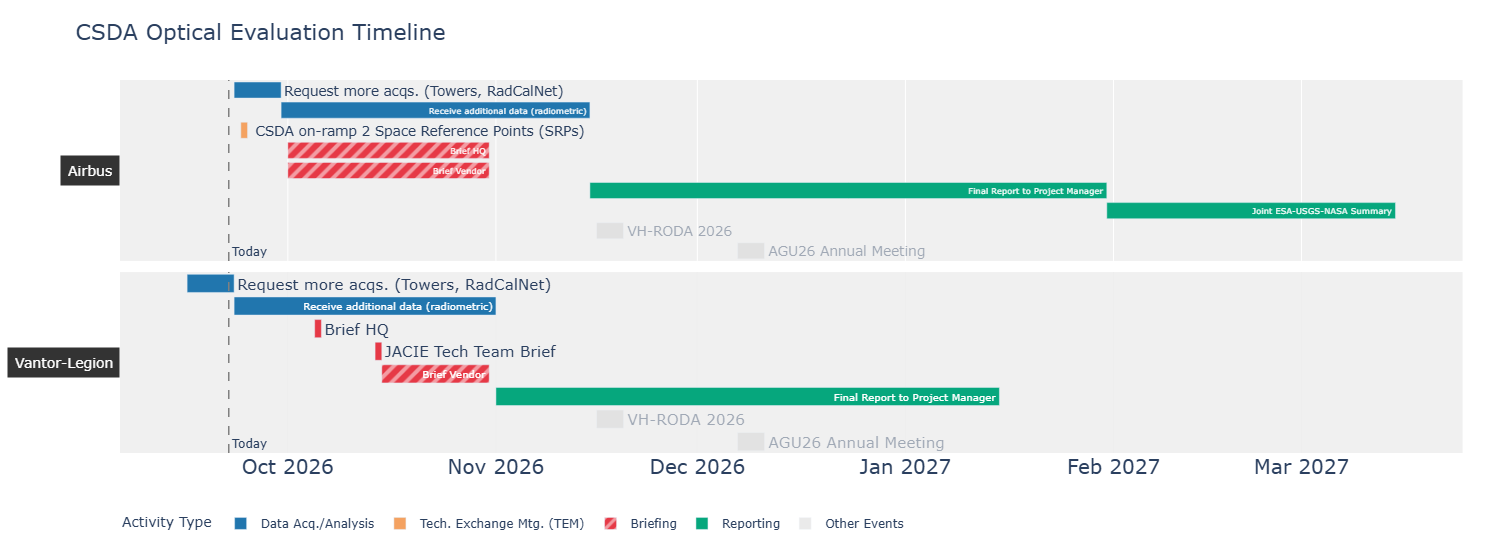

In [31]:
# ── Other Events (appears in every evaluation panel) ─────────────────────────
other_events = [
    dict(Evaluation=ev, Task='VH-RODA 2026',
         Start='2026-11-16', Finish='2026-11-20', Type='Other Events',
         Notes='VH-RODA 2026 | Frascati, Italy',
         flag=None)
    for ev in evaluations_list
] + [
    dict(Evaluation=ev, Task='AGU26 Annual Meeting',
         Start='2026-12-07', Finish='2026-12-11', Type='Other Events',
         Notes='AGU26 Annual Meeting | Moscone Center, San Francisco, CA',
         flag=None)
    for ev in evaluations_list
]

tasks = [

    
    # ── Airbus ────────────────────────────────────────────────────────────────
    dict(Evaluation='Airbus', Task=' CSDA on-ramp 2 Space Reference Points (SRPs)',
     Start='2026-09-24', Finish='2026-09-24', Type='Tech. Exchange Mtg. (TEM)',
     Notes='3:00–4:30 PM | MS Teams | Airbus & CSDA TEM: sensor capabilities, cal/val, '
           'product offerings, file naming, metadata standards, spectral response, '
           'geolocation accuracy. Materials handled as CUI.',
     flag=None),
    dict(Evaluation='Airbus', Task='Request more acqs. (Towers, RadCalNet)',
         Start='2026-09-23', Finish='2026-09-30', Type='Data Acq./Analysis', flag=None,
         Notes='Submit request to data management team for additional radiometric QA data'),
    dict(Evaluation='Airbus', Task='Receive additional data (radiometric)',
         Start='2026-09-30', Finish='2026-11-15', Type='Data Acq./Analysis', flag=None,
         Notes='Estimated receipt by 11/15/26'),
    dict(Evaluation='Airbus', Task='Brief HQ',
         Start='2026-10-01', Finish='2026-10-31', Type='Briefing', flag='pending',
         Notes='Discuss at 9/22/26 meeting'),
    dict(Evaluation='Airbus', Task='Brief Vendor',
         Start='2026-10-01', Finish='2026-10-31', Type='Briefing', flag='pending',
         Notes='Discuss at 9/22/26 meeting'),
    dict(Evaluation='Airbus', Task='Final Report to Project Manager',
         Start='2026-11-15', Finish='2027-01-31', Type='Reporting', flag=None,
         Notes='Estimated delivery 1/31/27'),
    dict(Evaluation='Airbus', Task='Joint ESA-USGS-NASA Summary',
         Start='2027-01-31', Finish='2027-03-15', Type='Reporting', flag=None,
         Notes='Target 3/15/27'),

    # ── Vantor-Legion ─────────────────────────────────────────────────────────
    dict(Evaluation='Vantor-Legion', Task='JACIE Tech Team Brief',
     Start='2026-10-14', Finish='2026-10-14', Type='Briefing', flag=None,
     Notes='NASA briefs Legion results at JACIE Tech Team virtual meeting (10/14/26)'),
    
    dict(Evaluation='Vantor-Legion', Task='Request more acqs. (Towers, RadCalNet)',
         Start='2026-09-16', Finish='2026-09-23', Type='Data Acq./Analysis', flag=None,
         Notes='Started 9/16/26; target finish 9/23/26'),
    dict(Evaluation='Vantor-Legion', Task='Receive additional data (radiometric)',
         Start='2026-09-23', Finish='2026-11-01', Type='Data Acq./Analysis', flag=None,
         Notes='Estimated receipt by 11/1/26'),
    dict(Evaluation='Vantor-Legion', Task='Brief HQ',
         Start='2026-10-05', Finish='2026-10-05', Type='Briefing', flag=None,
         Notes='Delayed due to data delays, vacations, and HQ availability. Invite Chris Neigh.'),
    dict(Evaluation='Vantor-Legion', Task='Brief Vendor',
         Start='2026-10-15', Finish='2026-10-31', Type='Briefing', flag='pending',
         Notes='Fritz to coordinate timing with Amy'),
    dict(Evaluation='Vantor-Legion', Task='Final Report to Project Manager',
         Start='2026-11-01', Finish='2027-01-15', Type='Reporting', flag=None,
         Notes='Estimated delivery 1/15/27'),
]

# ── Append other events ───────────────────────────────────────────────────────

tasks += other_events

df = pd.DataFrame(tasks)

# ── Datetime conversion ───────────────────────────────────────────────────────
df['Start']  = pd.to_datetime(df['Start'])
df['Finish'] = pd.to_datetime(df['Finish'])

# ── Make same-day entries visible ─────────────────────────────────────────────
mask = df['Start'] == df['Finish']
df.loc[mask, 'Finish'] = df.loc[mask, 'Start'] + pd.Timedelta(days=1)

# ── Pre-formatted date strings for hover ──────────────────────────────────────
df['Start_str']  = df['Start'].dt.strftime('%b %d, %Y')
df['Finish_str'] = df['Finish'].dt.strftime('%b %d, %Y')

df['Label']      = df['Evaluation'] + ' | ' + df['Task']
df['Evaluation'] = pd.Categorical(df['Evaluation'],
                                   categories=evaluations_list, ordered=True)

type_order = ['Data Acq./Analysis', 'Tech. Exchange Mtg. (TEM)', 'Briefing', 'Reporting', 'Other Events']
df['Type'] = pd.Categorical(df['Type'], categories=type_order, ordered=True)
df = df.sort_values(['Evaluation', 'Type', 'Start']).reset_index(drop=True)

# ── Color map ─────────────────────────────────────────────────────────────────
color_map = {
    'Data Acq./Analysis': '#457B9D',
    'Briefing':        '#E63946',
    'Reporting':       '#2A9D8F',
    'Other Events':    '#CCCCCC',
}
color_map = {
    'Data Acq./Analysis':        '#2176AE',   # cerulean blue     (~205° split-complement of red)
    'Tech. Exchange Mtg. (TEM)': '#F4A261',   # warm sandy orange (~30°  analogous to red, desaturated)
    'Briefing':                  '#E63946',   # red               (~355° anchor — unchanged)
    'Reporting':                 '#06A77D',   # emerald teal      (~165° split-complement of red)
    'Other Events':              '#CCCCCC',   # neutral gray      (unchanged)
}

# ── Plot ──────────────────────────────────────────────────────────────────────
fig = px.timeline(
    df,
    x_start    = 'Start',
    x_end      = 'Finish',
    y          = 'Task',
    color      = 'Type',
    facet_row  = 'Evaluation',
    text       = 'Task',
    color_discrete_map = color_map,
    title      = 'CSDA Optical Evaluation Timeline',
    hover_data = {
        'Task':       True,
        'Start':      False,
        'Finish':     False,
        'Start_str':  True,
        'Finish_str': True,
        'Type':       True,
        'Notes':      True,
        'flag':       False,    # ← used for pattern logic, not shown
        'Evaluation': False,
    },
    labels         = {'Task': '', 'Type': 'Activity Type'},
    category_orders = {'Type': type_order},
)

# ── Build yaxis → Evaluation mapping from facet layout ───────────────────────
# yaxis_to_eval = {}
# for i, ev in enumerate(evaluations_list):
#     key = 'y' if i == 0 else f'y{i + 1}'
#     yaxis_to_eval[key] = ev

# ── Dynamic version: Plotly assigns y-axes bottom-to-top, so reverse the list ─
yaxis_keys = ['y'] + [f'y{i+1}' for i in range(1, len(evaluations_list))]
yaxis_to_eval = dict(zip(yaxis_keys, reversed(evaluations_list)))
print(yaxis_to_eval)   # verify before using

# ── Apply diagonal hatch to 'pending' bars ────────────────────────────────────
for trace in fig.data:
    if trace.name == 'Other Events':
        trace.update(opacity=0.4)
        continue

    # ── Identify which Evaluation this trace belongs to ───────────────────────
    eval_name  = yaxis_to_eval.get(trace.yaxis, None)
    task_names = list(trace.y)
    patterns   = []

    for task in task_names:
        # ── Match on BOTH Task AND Evaluation to avoid cross-eval collisions ──
        match = df[(df['Task'] == task) & (df['Evaluation'] == eval_name)]

        if not match.empty and match.iloc[0]['flag'] == 'pending':
            patterns.append('/')
        else:
            patterns.append('')

    trace.update(
        marker = dict(
            pattern = dict(
                shape    = patterns,
                solidity = 0.4,
                fgcolor  = 'white',
            )
        )
    )

# ── Custom hover template ─────────────────────────────────────────────────────
fig.update_traces(
    hovertemplate = (
        '<b>%{y}</b><br>'
        'Start:  %{base|%b %d, %Y}<br>'
        'Finish: %{x|%b %d, %Y}<br>'
        'Type:   %{customdata[0]}<br>'
        '<i>%{customdata[1]}</i>'
        '<extra></extra>'
    ),
    textposition     = 'inside',
    insidetextanchor = 'middle',
    textfont         = dict(size=14, color='white'),
    selector         = dict(name__ne='Other Events'),  # ← don't override Other Events text
)

# ── Facet labels on left ──────────────────────────────────────────────────────
fig.for_each_annotation(lambda a: a.update(
    text      = a.text.split("=")[-1],
    font      = dict(size=14, color='white'),
    textangle = 0,
    bgcolor   = '#333333',
    borderpad = 6,
    x         = 0,
    xanchor   = 'right',
    xref      = 'paper',
))

fig.update_yaxes(
    autorange      = 'reversed',
    matches        = None,
    showticklabels = False,
)

# ── Today line ────────────────────────────────────────────────────────────────
today_ms = pd.Timestamp.today().value / 1e6
fig.add_vline(
    x                    = today_ms,
    line_dash            = 'dash',
    line_color           = 'gray',
    line_width           = 1.5,
    annotation_text      = 'Today',
    annotation_position  = 'bottom right',
    annotation_font_size = 12,
)

fig.update_layout(
    height       = 200 * len(evaluations_list) + 150,
    xaxis_title  = '',
    yaxis_title  = '',
    font         = dict(size=16),
    legend       = dict(orientation='h', y=-0.15, font=dict(size=12)),
    plot_bgcolor = '#f0f0f0',
    xaxis        = dict(
        showgrid    = True,
        gridcolor   = '#eeeeee',
        tickformat  = '%b %Y',
        dtick       = 'M1',
        tickfont    = dict(size=20),
    ),
    margin = dict(l=120, r=20, t=80, b=60),
)

fig.show()